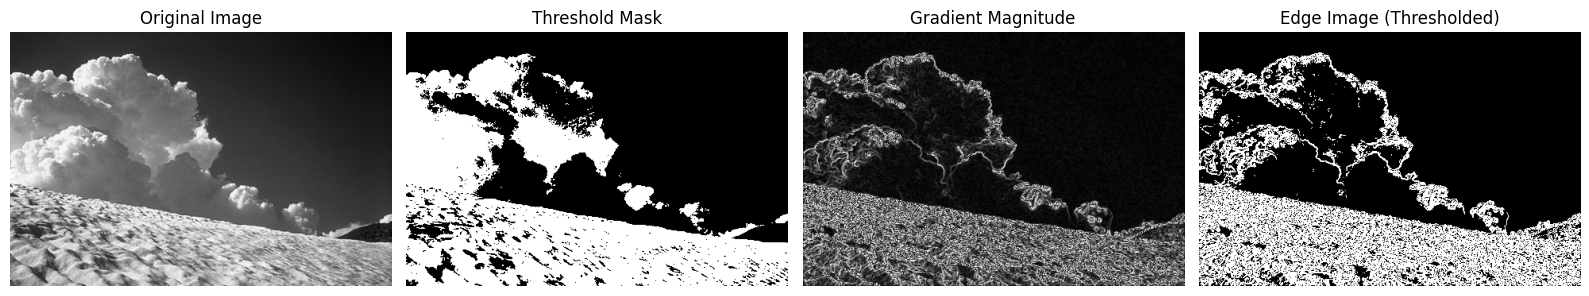

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 1. Manzilni belgilaymiz (Train papkasidan rasmlarni olamiz)
base_path = '/content/drive/MyDrive/DIP/archive/images/train/'
# Papkadagi barcha rasm fayllarini topish (kengaytmasi .jpg yoki .png bo'lishi mumkin)
image_files = glob.glob(base_path + '*.*')

# Choosing one image
first_image_path = image_files[0]
image = cv2.imread(first_image_path, cv2.IMREAD_GRAYSCALE) # Oq-qora qilib o'qiymiz

# 2. Thresholding yordamida maska yaratish (masalan, 127 dan kattasini oq, kichigini qora qilamiz)
_, mask = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# 3. Gradientlar yordamida qirralarni (edge) aniqlash (Sobel operatori)
grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3) # X o'qi bo'yicha
grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3) # Y o'qi bo'yicha
gradient_magnitude = cv2.magnitude(grad_x, grad_y) # Umumiy magnituda
gradient_magnitude = np.uint8(np.absolute(gradient_magnitude)) # Rasm formatiga o'tkazish

# 4. Gradient magnitudasiga threshold berib, qirra (edge) rasmini yaratish
_, edge_image = cv2.threshold(gradient_magnitude, 50, 255, cv2.THRESH_BINARY)

# 5. Barcha natijalarni birga ko'rsatish (Show all results together)
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask, cmap='gray')
plt.title('Threshold Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(edge_image, cmap='gray')
plt.title('Edge Image (Thresholded)')
plt.axis('off')

plt.tight_layout()
plt.show()

Yangi papka yaratildi: /content/drive/MyDrive/DIP/archive/generated_masks/
Maskalarni yaratish va saqlash jarayoni boshlandi...
Barcha maskalar muvaffaqiyatli saqlandi! (201 ta rasm)


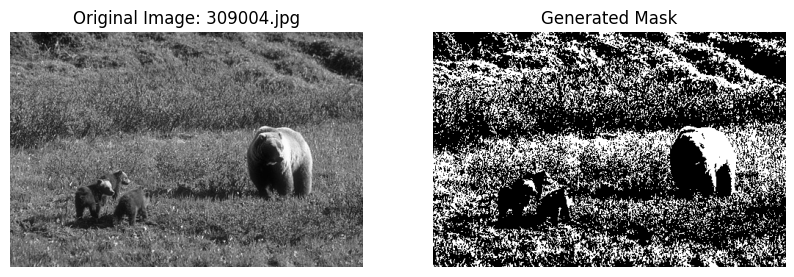

In [2]:
# 7. Creta a file for saving masks
save_dir = '/content/drive/MyDrive/DIP/archive/generated_masks/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"New folder created: {save_dir}")

# 8. Mark one threshold for whole dataset
GLOBAL_THRESHOLD = 127

print("Maskalarni yaratish va saqlash jarayoni boshlandi...")

# 6 & 9. Apply for whole dataset and generating masks
for img_path in image_files:
    # Subtract file names (masalan, "image01.jpg")
    filename = os.path.basename(img_path)

    # Reading an image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Creating a mask
    _, mask = cv2.threshold(img, GLOBAL_THRESHOLD, 255, cv2.THRESH_BINARY)

    # Show the saving way and save mask
    save_path = os.path.join(save_dir, filename)
    cv2.imwrite(save_path, mask)

print(f"Barcha maskalar muvaffaqiyatli saqlandi! ({len(image_files)} ta rasm)")

# 10. One original image and show its mask
# Show for checking the latest worked image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(f'Original Image: {filename}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Generated Mask')
plt.axis('off')

plt.show()